In [12]:
# Tự xây tool bằng @tool của langchain-core, gọi thẳng API gốc.
# Không dùng wrapper của langchain-community (đã sunset) hay thư viện `wikipedia` (bản 1.4.0 từ 2014, hay lỗi).
import re
import requests
import arxiv as arxiv_lib
from langchain_core.tools import tool
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler

load_dotenv()

langfuse_trace = CallbackHandler()


In [2]:
# Cấu hình tra cứu arxiv
ARXIV_TOP_K = 2          # số kết quả trả về
ARXIV_MAX_CHARS = 500    # độ dài tối đa của summary mỗi bài

# Regex nhận diện arXiv ID (vd: 1706.03762, hep-th/9901001) để tra theo id thay vì full-text
_ARXIV_ID = re.compile(r"\d{4}\.\d{4,5}(v\d+)?$|[a-z\-]+(\.[A-Z]{2})?/\d{7}(v\d+)?$")
_arxiv_client = arxiv_lib.Client()


@tool
def arxiv(query: str) -> str:
    """
    Search arXiv for academic and scientific research papers.

    Best used for research topics, paper summaries, literature reviews,
    machine learning, AI, computer science, mathematics, and physics.

    Input: a research query, paper title, keyword, or arXiv ID.
    Output: publication date, title, authors, and paper abstract.
    """
    if _ARXIV_ID.match(query.strip()):
        search = arxiv_lib.Search(id_list=query.split(), max_results=ARXIV_TOP_K)
    else:
        search = arxiv_lib.Search(
            query=query[:300],
            max_results=ARXIV_TOP_K,
            sort_by=arxiv_lib.SortCriterion.Relevance,
        )
    docs = []
    for r in _arxiv_client.results(search):
        authors = ", ".join(a.name for a in r.authors)
        docs.append(
            f"Published: {r.published.date()}\n"
            f"Title: {r.title}\n"
            f"Authors: {authors}\n"
            f"Summary: {r.summary[:ARXIV_MAX_CHARS]}"
        )
    return "\n\n".join(docs) if docs else "No good arXiv results found."


print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a\n\nPublished: 2025-12-03\nTitle: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme\nAuthors: Anton Alyakin\nSummary: The 2017 paper \'\'Attention Is All You Need\'\' introduced the Transformer architecture-and inadvertently spawned one of machine learning\'s most persistent naming conventions. 

In [4]:
# Cấu hình tra cứu Wikipedia
WIKI_TOP_K = 1           # số trang trả về
WIKI_MAX_CHARS = 500     # độ dài tối đa của summary mỗi trang
WIKI_LANG = "en"         # ngôn ngữ (vd: "en", "vi")

_WIKI_API = f"https://{WIKI_LANG}.wikipedia.org/w/api.php"
# Wikimedia yêu cầu User-Agent mô tả rõ ứng dụng; thiếu nó dễ bị chặn -> response rỗng -> JSONDecodeError
_WIKI_HEADERS = {"User-Agent": "ultimate-rag-bootcamp/1.0 (educational project)"}

@tool
def wiki(query: str) -> str:
    """
    Search Wikipedia for factual information and encyclopedia-style summaries.

    Best used for general knowledge, people, places, organizations,
    historical events, scientific concepts, and topic overviews.

    Input: a search query.
    Output: the most relevant Wikipedia page title and summary.
    """

    # 1) Tìm các trang khớp với truy vấn
    resp = requests.get(
        _WIKI_API,
        params={"action": "query", "list": "search", "srsearch": query,
                "srlimit": WIKI_TOP_K, "format": "json"},
        headers=_WIKI_HEADERS, timeout=10,
    )
    resp.raise_for_status()
    hits = resp.json().get("query", {}).get("search", [])
    if not hits:
        return "No good Wikipedia Search Result was found"

    # 2) Lấy phần tóm tắt (plain text) cho từng trang
    docs = []
    for hit in hits:
        title = hit["title"]
        page = requests.get(
            _WIKI_API,
            params={"action": "query", "prop": "extracts", "explaintext": 1,
                    "titles": title, "redirects": 1, "format": "json"},
            headers=_WIKI_HEADERS, timeout=10,
        )
        page.raise_for_status()
        pages = page.json().get("query", {}).get("pages", {})
        extract = next(iter(pages.values()), {}).get("extract", "")
        docs.append(f"Page: {title}\nSummary: {extract[:WIKI_MAX_CHARS]}")
    return "\n\n".join(docs)


print(wiki.name)

wiki


In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation methods compose the foundations o'

In [29]:
### Tavily Search Tool
# from langchain_community.tools.tavily_search import TavilySearchResults
# from datetime import datetime

# tavily = TavilySearchResults(
#     max_results=2,
# )

from langchain_tavily import TavilySearch
tavily = TavilySearch(max_results=2)

@tool
def web_search(query: str) -> str:
    """
    Search the web for current and real-time information.

    Best used for news, recent developments, live events,
    trending topics, and up-to-date information.

    Input: a search query.
    Output: summarized web search results with source links.
    """
    # TavilySearch.invoke() trả về dict {"query", "results", "answer", ...},
    # danh sách kết quả nằm trong khóa "results".
    response = tavily.invoke(query)
    results = response.get("results", []) if isinstance(response, dict) else response

    docs = []
    for item in results:
        docs.append(
            f"Title: {item.get('title', '')}\n"
            f"Content: {item.get('content', '')}\n"
            f"URL: {item.get('url', '')}"
        )

    return "\n\n".join(docs) if docs else "No relevant web results found."


In [30]:
### Combine all the tools in the list
tools = [arxiv, wiki, web_search]

In [ ]:
### Initialize ChatGroq LLM model

# from langchain_groq import ChatGroq

# llm = ChatGroq(model="llama-3.1-8b-instant")
# llm_with_tools = llm.bind_tools(tools)

In [ ]:
### Initialize ChatOllama LLM model

from langchain_ollama import ChatOllama

# llm = ChatOllama(model="qwen3")
llm = ChatOllama(model="granite4")
llm_with_tools = llm.bind_tools(tools)

In [13]:
from langchain_core.messages import AIMessage, HumanMessage


result = llm_with_tools.invoke([
    HumanMessage(
        content=f"What is the recent AI News"
    ),
], config={"callbacks": [langfuse_trace]})
result

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'granite4', 'created_at': '2026-06-25T08:02:28.550378293Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3718812225, 'load_duration': 800945934, 'prompt_eval_count': 411, 'prompt_eval_duration': 90280000, 'eval_count': 34, 'eval_duration': 2818390000, 'logprobs': None, 'model_name': 'granite4', 'model_provider': 'ollama'}, id='lc_run--019efdcd-35ba-71e3-a8f9-987d5ba99eef-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'latest artificial intelligence news July 2025'}, 'id': 'd8ad4bc9-c852-4dfb-a69d-d6262470eced', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 411, 'output_tokens': 34, 'total_tokens': 445})

In [11]:
result.tool_calls

[{'name': 'web_search',
  'args': {'query': 'latest AI news August 2025'},
  'id': 'a700ceea-f371-4722-9aad-7c21e434577b',
  'type': 'tool_call'}]

In [32]:
### State Schema
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [33]:
### Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

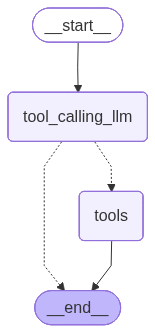

In [34]:
### Node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tools.invoke(state["messages"], config={
                "callbacks": [langfuse_trace]
            })
        ]
    }

# Build graph
builder = StateGraph(State)

# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

# Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)

builder.add_edge("tools", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [35]:
messages = graph.invoke(
    {
        "messages": HumanMessage(
            # content = f"What is attention is all you need"
            content = f"1706.03762"
        )
    },
    config={
        "callbacks": [langfuse_trace]
    }
)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (da07e29f-4988-4d84-9acf-fdff0e4609b5)
 Call ID: da07e29f-4988-4d84-9acf-fdff0e4609b5
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2017-06-12
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experime

In [37]:
from datetime import datetime

messages = graph.invoke(
    {
        "messages": HumanMessage(
            content = f"Provide me the top 2 recent AI news for today: {datetime.today()}"
        )
    },
    config={
        "callbacks": [langfuse_trace]
    }
)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 2 recent AI news for today: 2026-06-25 15:45:35.633476
================================== Ai Message ==================================
Tool Calls:
  web_search (464ba98c-b158-4ff3-8e72-dcbe29f4cecc)
 Call ID: 464ba98c-b158-4ff3-8e72-dcbe29f4cecc
  Args:
    query: AI news June 25 2026
================================= Tool Message =================================
Name: web_search

Title: Google Search's I/O 2026 updates: AI agents and more
Content: [Skip to main content](https://blog.google/products-and-platforms/products/search/search-io-2026#jump-content). *   [See all](https://blog.google/innovation-and-ai/products/). *   [Search](https://blog.google/products-and-platforms/products/search/). *   [Search](https://blog.google/products-and-platforms/products/search/). *   [What's new in Android 17?](https://blog.google/products-and-platforms/products/search/search-io-2026#). *   [How 

In [38]:
messages = graph.invoke(
    {
        "messages": HumanMessage(
            content = f"What is machine learning"
        )
    },
    config={
        "callbacks": [langfuse_trace]
    }
)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wiki (5214ddb3-e10a-4b31-b0cd-3992f6658125)
 Call ID: 5214ddb3-e10a-4b31-b0cd-3992f6658125
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wiki

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation methods compose the foundations o
